# 01 Data Understanding

Phase 1 reviews the manually provided LendingClub-style raw dataset, defines the starter default target, documents schema and missingness, and creates a small modeling-ready sample for the next phase. No PD model, ECL engine, or dashboard logic is built in this notebook.

## Project Context

This project is a finance and risk analytics portfolio project focused on credit risk and IFRS 9 Expected Credit Loss. Phase 1 is limited to data understanding, schema review, target definition, initial exploratory analysis, and preparation of a small modeling-ready sample.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import FIGURES_DIR, PROCESSED_DATA_DIR, RAW_DATA_DIR
from src.data_prep import (
    find_raw_dataset,
    get_candidate_features,
    load_raw_data,
    map_loan_status_to_target,
    summarize_schema,
)
from src.visualization import (
    plot_default_rate_by_category,
    plot_missing_values,
    plot_numeric_distribution,
    plot_target_distribution,
)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

## Dataset Loading

The dataset is detected from `data/raw/`. Plain `.csv` and compressed `.csv.gz` files are treated as CSV-style files. If multiple CSV-style files exist, the largest file is selected for Phase 1.

In [2]:
csv_files = sorted(
    [path for path in RAW_DATA_DIR.iterdir() if path.is_file() and (path.suffix == ".csv" or path.name.endswith(".csv.gz"))],
    key=lambda path: path.stat().st_size,
    reverse=True,
)
dataset_path = find_raw_dataset()

display(pd.DataFrame({
    "file": [path.name for path in csv_files],
    "size_mb": [round(path.stat().st_size / 1_000_000, 2) for path in csv_files],
}))

if len(csv_files) > 1:
    print(f"Multiple CSV-style files found. Selected the largest file: {dataset_path.name}")
else:
    print(f"Selected dataset file: {dataset_path.name}")

SAMPLE_SIZE = 50_000
df = load_raw_data(sample_size=SAMPLE_SIZE)
print(f"Loaded {len(df):,} rows for Phase 1 exploration from {dataset_path.name}.")

,file,size_mb
0,accepted_2007_to_2018Q4.csv.gz,392.58
1,rejected_2007_to_2018Q4.csv.gz,255.47


Multiple CSV-style files found. Selected the largest file: accepted_2007_to_2018Q4.csv.gz
Loaded 50,000 rows for Phase 1 exploration from accepted_2007_to_2018Q4.csv.gz.


## Dataset Shape and Columns

In [3]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
display(pd.DataFrame({"columns": df.columns.tolist()}))
display(df.head())

Rows: 50,000
Columns: 151


,columns
0,id
1,member_id
2,loan_amnt
3,funded_amnt
4,funded_amnt_inv
...,...
146,settlement_status
147,settlement_date
148,settlement_amount
149,settlement_percentage


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,...,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,30.0,NaN,7.0,0.0,2765.0,29.7,13.0,w,0.00,0.00,4421.723917,4421.72,3600.00,821.72,0.0,0.0,0.0,Jan-2019,122.67,NaN,Mar-2019,564.0,560.0,0.0,30.0,1.0,Individual,NaN,NaN,NaN,...,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,6.0,NaN,22.0,0.0,21470.0,19.2,38.0,w,0.00,0.00,25679.660000,25679.66,24700.00,979.66,0.0,0.0,0.0,Jun-2016,926.35,NaN,Mar-2019,699.0,695.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,...,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,truck driver,10+ years,MORTGAGE,63000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,home_improvement,NaN,605xx,IL,10.78,0.0,Aug-2000,695.0,699.0,0.0,NaN,NaN,6.0,0.0,7869.0,56.2,18.0,w,0.00,0.00,22705.924294,22705.92,20000.00,2705.92,0.0,0.0,0.0,Jun-2017,15813.30,NaN,Mar-2019,704.0,700.0,0.0,NaN,1.0,Joint App,71000.0,13.85,Not Verified,...,10.0,NaN,0.0,2.0,3.0,2.0,4.0,6.0,4.0,7.0,3.0,6.0,0.0,0.0,0.0,0.0,100.0,50.0,0.0,0.0,218418.0,18696.0,6200.0,14877.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,Na

## Schema Summary

In [4]:
schema_summary = summarize_schema(df)
display(schema_summary.head(40))

,column,dtype,non_null_count,missing_count,missing_pct,unique_count
1,member_id,float64,0,50000,100.00,0
115,revol_bal_joint,float64,0,50000,100.00,0
125,sec_app_chargeoff_within_12_mths,float64,0,50000,100.00,0
126,sec_app_collections_12_mths_ex_med,float64,0,50000,100.00,0
118,sec_app_earliest_cr_line,float64,0,50000,100.00,0
117,sec_app_fico_range_high,float64,0,50000,100.00,0
116,sec_app_fico_range_low,float64,0,50000,100.00,0
119,sec_app_inq_last_6mths,float64,0,50000,100.00,0
120,sec_app_mort_acc,float64,0,50000,100.00,0
127,sec_app_mths_since_last_major_derog,float64,0,50000,100.00,0


## Missing Value Review

,column,missing_count,missing_pct
1,member_id,50000,100.00
120,sec_app_mort_acc,50000,100.00
115,revol_bal_joint,50000,100.00
122,sec_app_revol_util,50000,100.00
121,sec_app_open_acc,50000,100.00
124,sec_app_num_rev_accts,50000,100.00
127,sec_app_mths_since_last_major_derog,50000,100.00
123,sec_app_open_act_il,50000,100.00
119,sec_app_inq_last_6mths,50000,100.00
116,sec_app_fico_range_low,50000,100.00


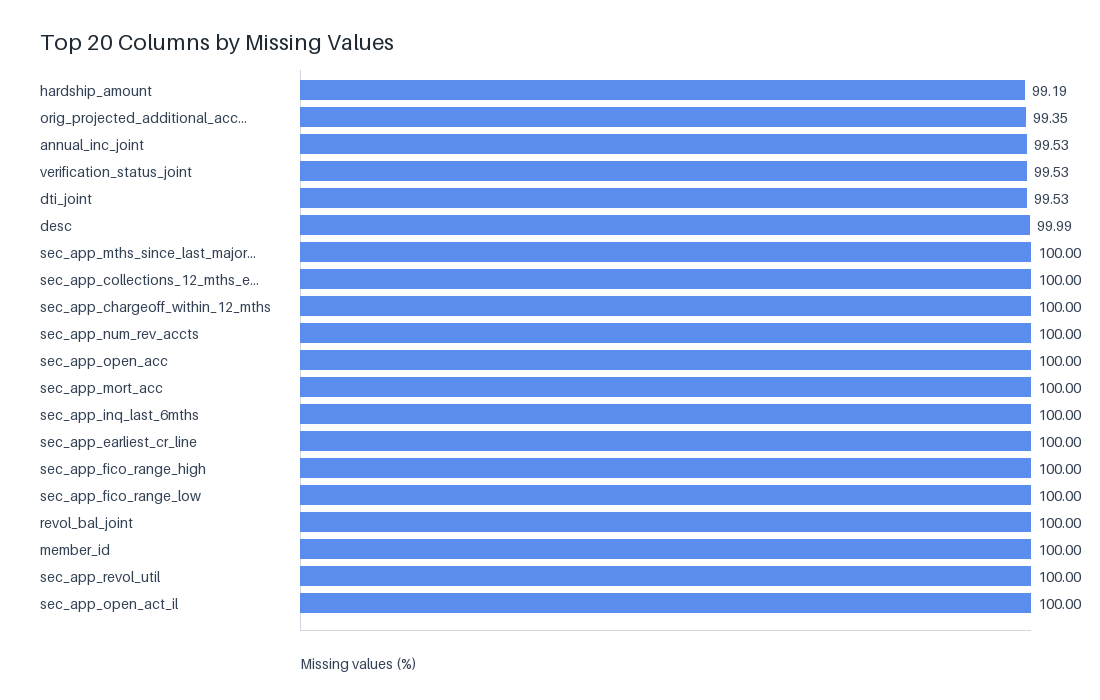

In [5]:
missing_top20 = schema_summary.sort_values("missing_pct", ascending=False).head(20)
display(missing_top20[["column", "missing_count", "missing_pct"]])

image = plot_missing_values(df, top_n=20)
image.save(FIGURES_DIR / "missing_values_top20.png")
display(image)

## Loan Status Review

In [6]:
if "loan_status" not in df.columns:
    raise KeyError("loan_status is required for Phase 1 target definition.")

loan_status_counts = df["loan_status"].astype("string").str.strip().value_counts(dropna=False)
display(loan_status_counts.to_frame("row_count"))

,row_count
loan_status,
Fully Paid,34978
Charged Off,9027
Current,5610
Late (31-120 days),246
In Grace Period,100
Late (16-30 days),38
Default,1


## Target Definition

The starter binary target is `default_flag`.

- `default_flag = 1`: `Charged Off`, `Default`, `Late (31-120 days)`, `Does not meet the credit policy. Status:Charged Off`
- `default_flag = 0`: `Fully Paid`, `Current`, `In Grace Period`, `Late (16-30 days)`, `Does not meet the credit policy. Status:Fully Paid`
- Unknown statuses are listed and excluded from the modeling-ready sample for now.

In [7]:
modeling_ready, unknown_statuses = map_loan_status_to_target(df)
print(f"Rows with known target mapping: {len(modeling_ready):,}")
print(f"Rows excluded because of unknown target status: {len(df) - len(modeling_ready):,}")
print("Unknown statuses:", unknown_statuses if unknown_statuses else "None")
display(modeling_ready[["loan_status", "default_flag"]].head())

Rows with known target mapping: 50,000
Rows excluded because of unknown target status: 0
Unknown statuses: None


,loan_status,default_flag
0,Fully Paid,0
1,Fully Paid,0
2,Fully Paid,0
3,Current,0
4,Fully Paid,0


## Target Distribution

,row_count,share
default_flag,,
0,40726,0.8145
1,9274,0.1855


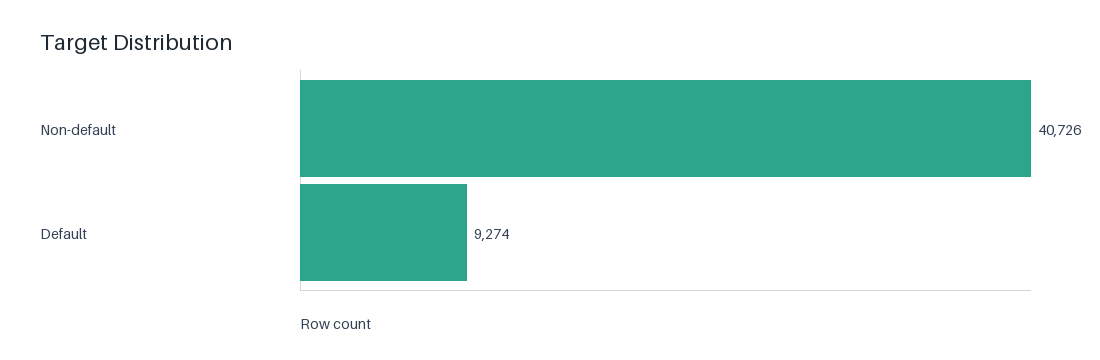

In [8]:
target_distribution = modeling_ready["default_flag"].value_counts(normalize=False).sort_index().to_frame("row_count")
target_distribution["share"] = modeling_ready["default_flag"].value_counts(normalize=True).sort_index().round(4)
display(target_distribution)

image = plot_target_distribution(modeling_ready, target_col="default_flag")
image.save(FIGURES_DIR / "target_distribution.png")
display(image)

## Candidate Risk Drivers

The candidate feature list is intentionally simple for Phase 1 and only includes columns that exist in the selected dataset. Final model features will be decided in Phase 2.

In [9]:
candidate_features = get_candidate_features(modeling_ready)
display(pd.DataFrame({"candidate_feature": candidate_features}))

modeling_sample_columns = ["default_flag"] + candidate_features
modeling_sample = modeling_ready[modeling_sample_columns].head(50_000).copy()
modeling_sample_path = PROCESSED_DATA_DIR / "modeling_sample.csv"
modeling_sample.to_csv(modeling_sample_path, index=False)
print(f"Saved modeling-ready sample: {modeling_sample_path}")
print(f"Modeling sample shape: {modeling_sample.shape}")

,candidate_feature
0,loan_amnt
1,term
2,int_rate
3,installment
4,grade
5,sub_grade
6,emp_length
7,home_ownership
8,annual_inc
9,verification_status


Saved modeling-ready sample: /Users/rovs/Documents/New project 2/projects/credit-risk-ifrs9-ecl-engine/data/processed/modeling_sample.csv
Modeling sample shape: (50000, 26)


## Initial EDA

Default rate by grade


,default_rate,row_count
grade,,
G,49.55,222
F,46.01,989
E,36.78,3496
D,29.82,6872
C,20.40,14516
B,12.84,15264
A,5.24,8641


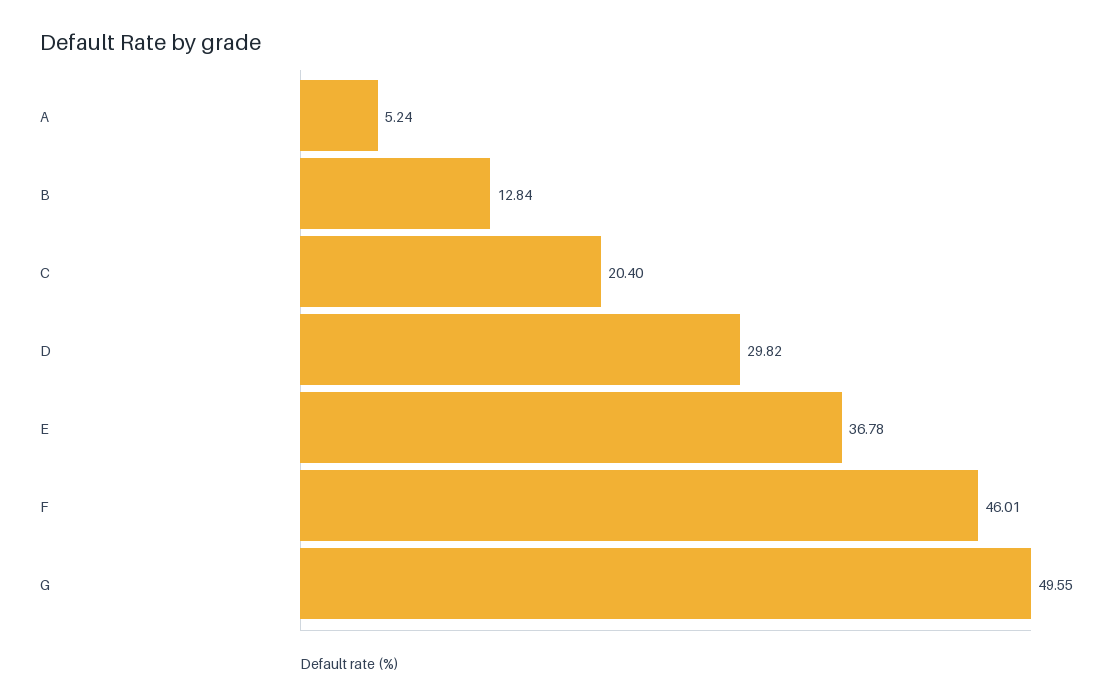

Default rate by sub_grade


,default_rate,row_count
sub_grade,,
G4,70.37,27
F5,61.95,113
F4,53.72,121
G3,52.38,42
F3,47.76,201
G1,47.06,68
F2,46.61,236
G2,44.29,70
E5,40.58,451


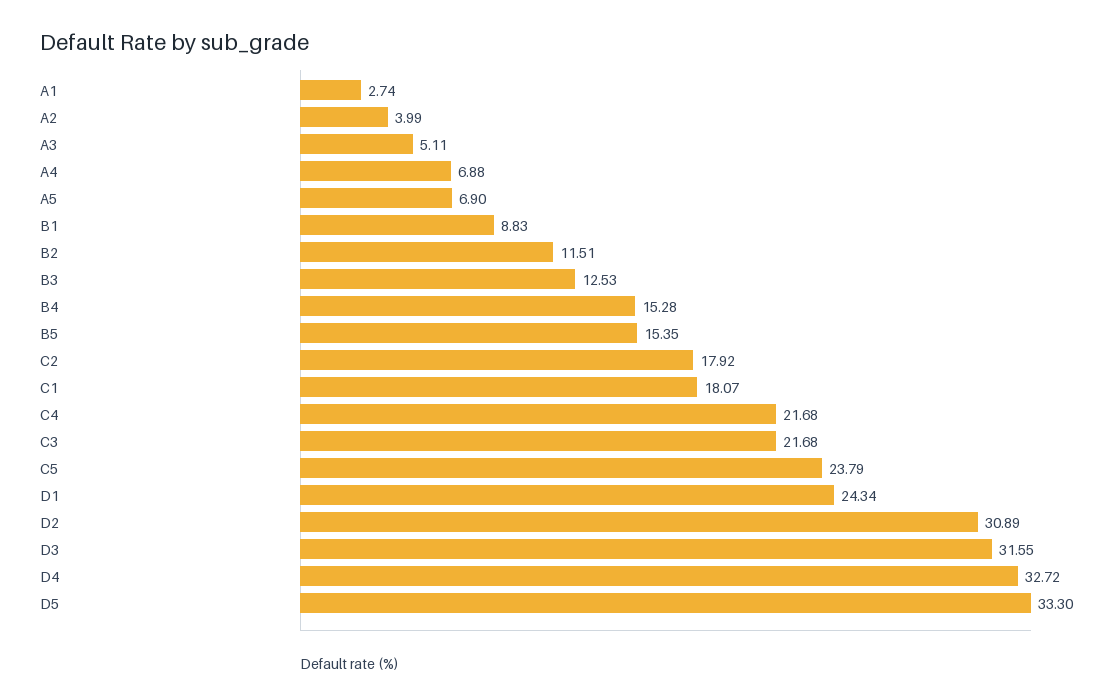

Default rate by term


,default_rate,row_count
term,,
60 months,25.29,15823
36 months,15.43,34177


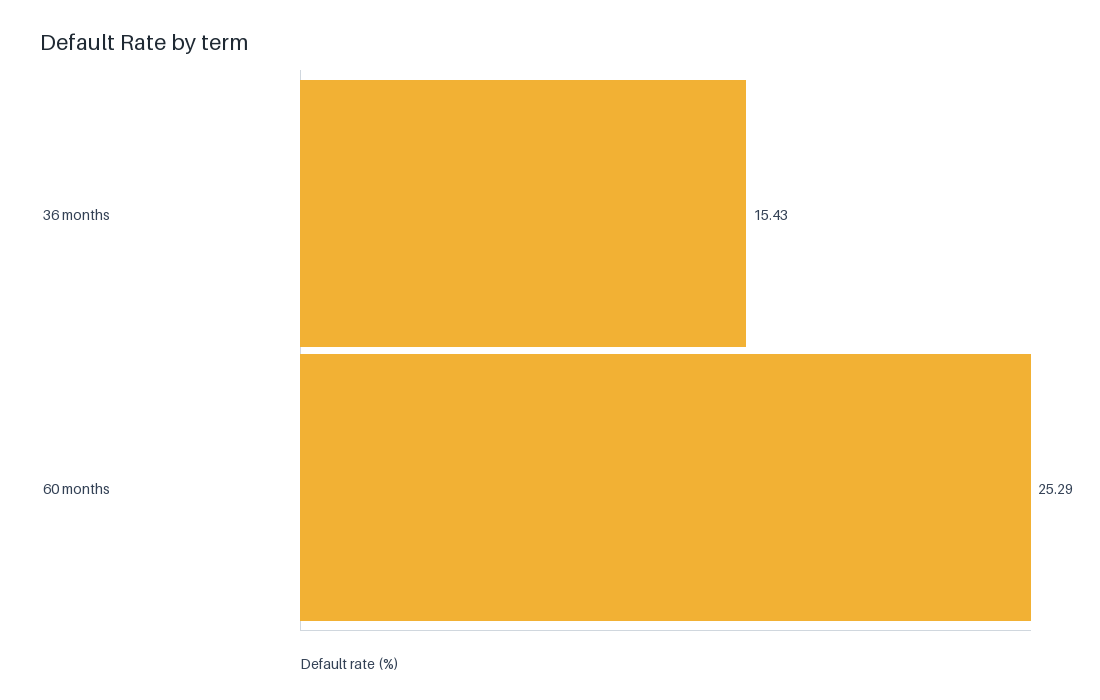

Default rate by home_ownership


,default_rate,row_count
home_ownership,,
RENT,21.86,19660
OWN,19.31,5753
MORTGAGE,15.72,24586
ANY,0.00,1


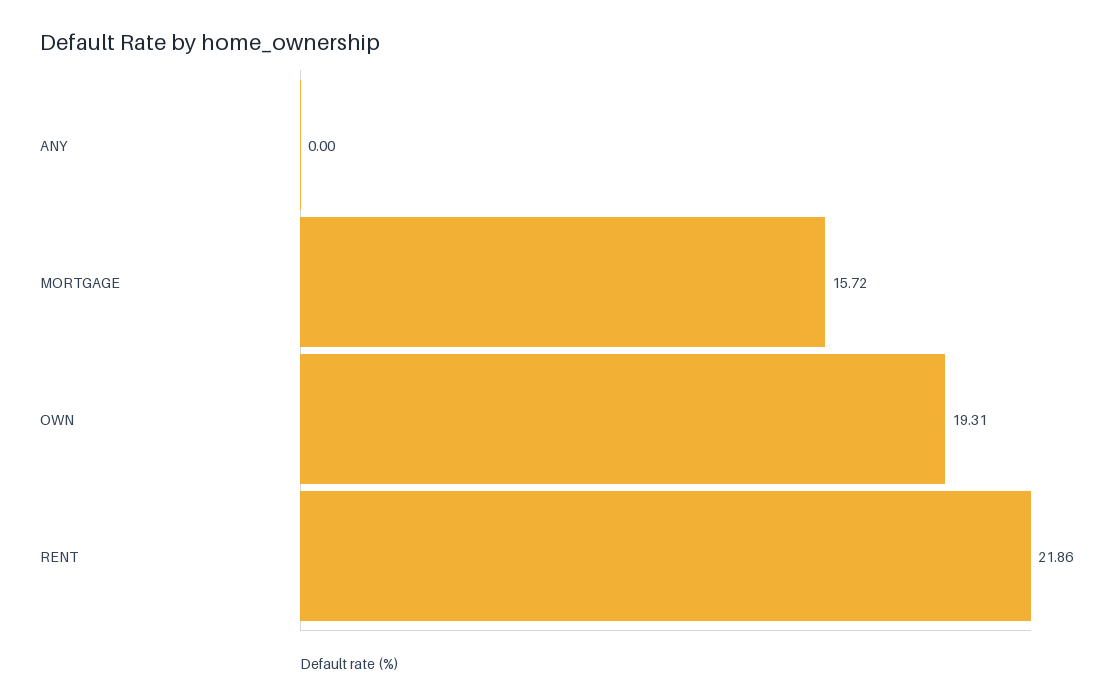

Default rate by purpose


,default_rate,row_count
purpose,,
small_business,28.84,482
house,25.68,183
moving,22.86,280
medical,21.61,583
debt_consolidation,20.01,28283
vacation,19.64,275
major_purchase,19.37,1048
other,18.12,2759
home_improvement,16.49,2977


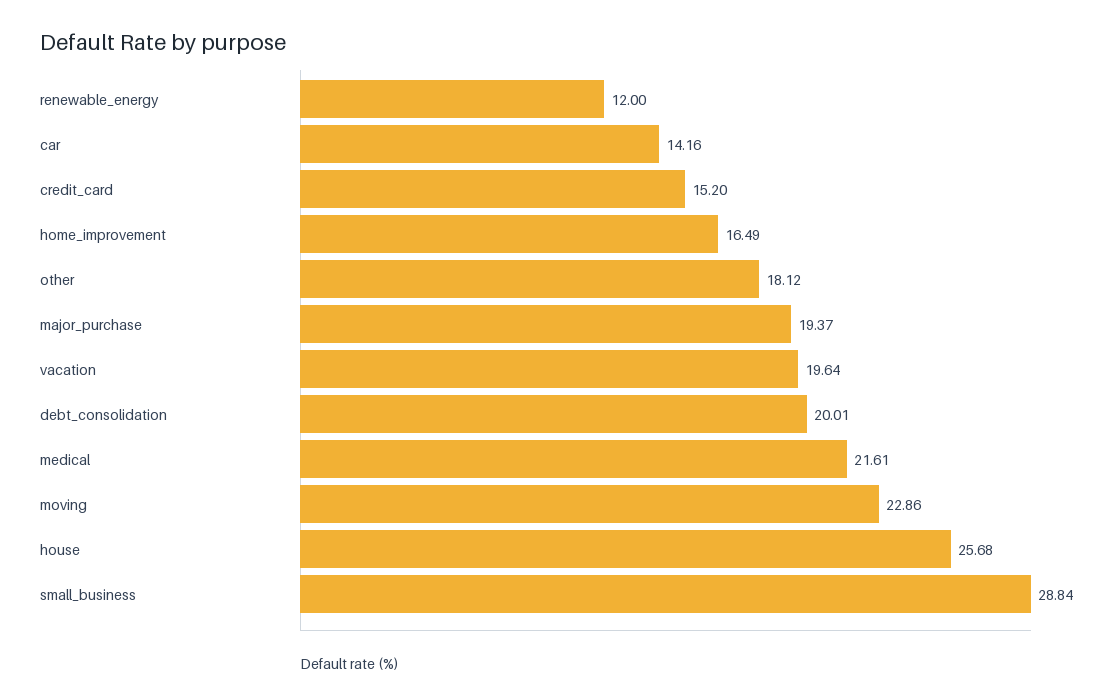

Default rate by verification_status


,default_rate,row_count
verification_status,,
Verified,23.43,15705
Source Verified,18.42,20677
Not Verified,13.11,13618


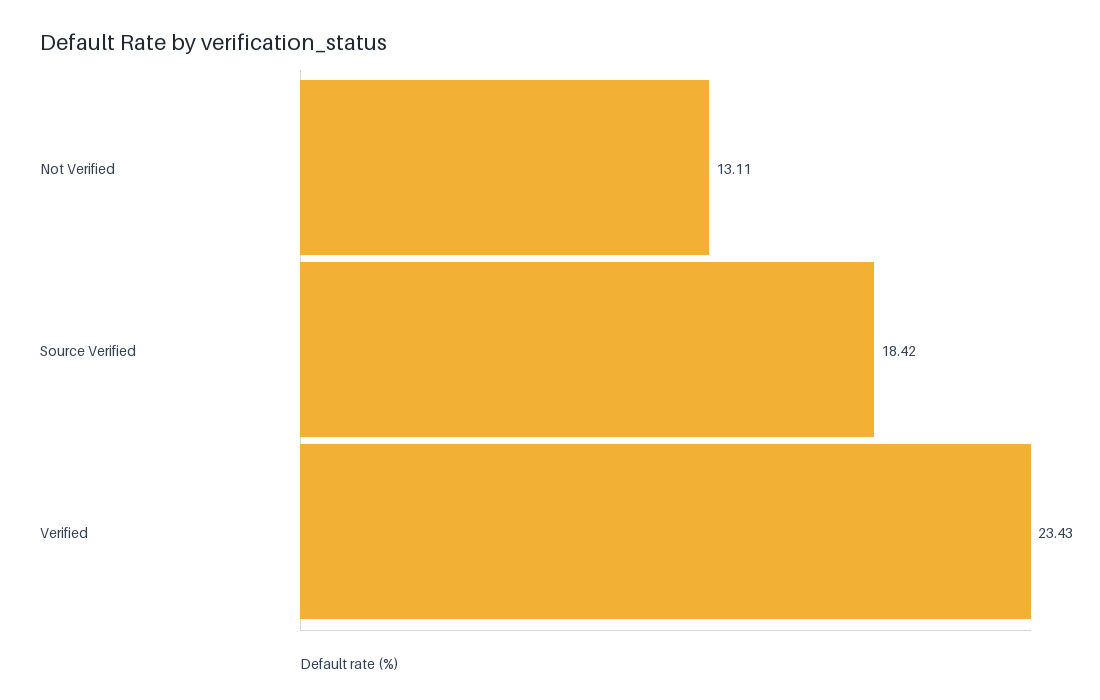

Saved category figures: ['default_rate_by_grade.png', 'default_rate_by_sub_grade.png', 'default_rate_by_term.png', 'default_rate_by_home_ownership.png', 'default_rate_by_purpose.png', 'default_rate_by_verification_status.png']


In [10]:
category_checks = ["grade", "sub_grade", "term", "home_ownership", "purpose", "verification_status"]
saved_category_figures = []

for column in category_checks:
    if column in modeling_ready.columns:
        rate_table = (
            modeling_ready.groupby(column, dropna=False)["default_flag"]
            .agg(default_rate="mean", row_count="size")
            .sort_values("default_rate", ascending=False)
        )
        rate_table["default_rate"] = (rate_table["default_rate"] * 100).round(2)
        print(f"Default rate by {column}")
        display(rate_table.head(25))

        image = plot_default_rate_by_category(modeling_ready, column, target_col="default_flag", top_n=20)
        figure_path = FIGURES_DIR / f"default_rate_by_{column}.png"
        image.save(figure_path)
        saved_category_figures.append(figure_path.name)
        display(image)
    else:
        print(f"Skipped {column}: column not available.")

print("Saved category figures:", saved_category_figures)

Numeric summary for loan_amnt


,loan_amnt
count,50000.000000
mean,15019.359500
std,8676.103295
min,1000.000000
25%,8000.000000
50%,14000.000000
75%,20000.000000
max,35000.000000


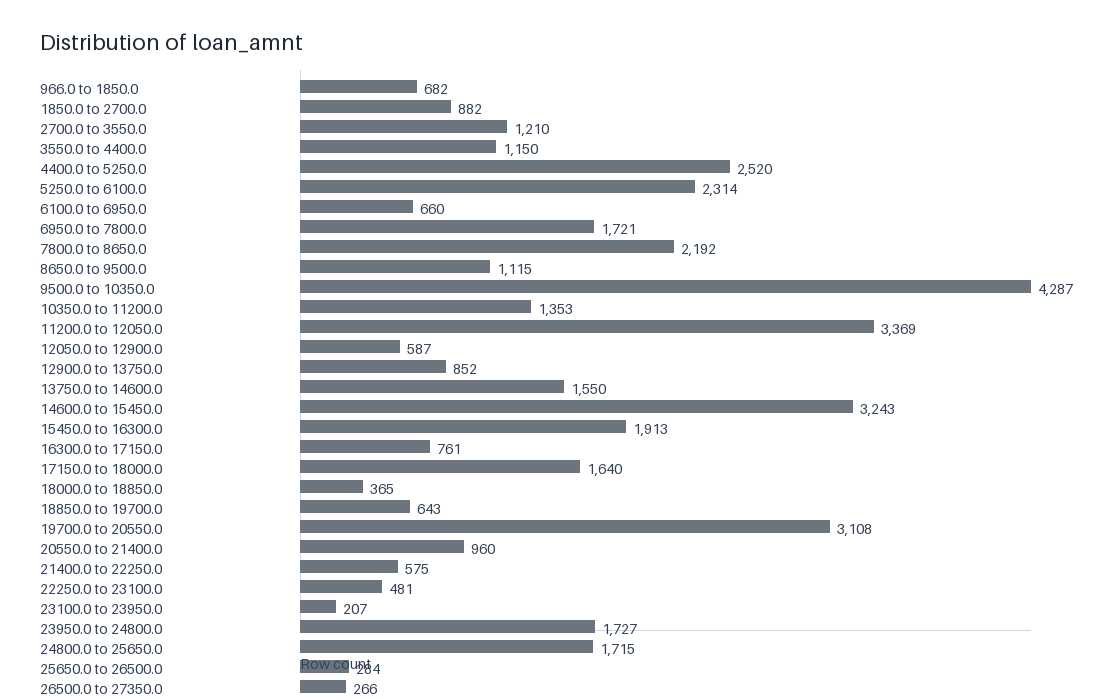

Numeric summary for int_rate


,int_rate
count,50000.000000
mean,12.234782
std,4.191338
min,5.320000
25%,9.170000
50%,11.990000
75%,14.480000
max,28.990000


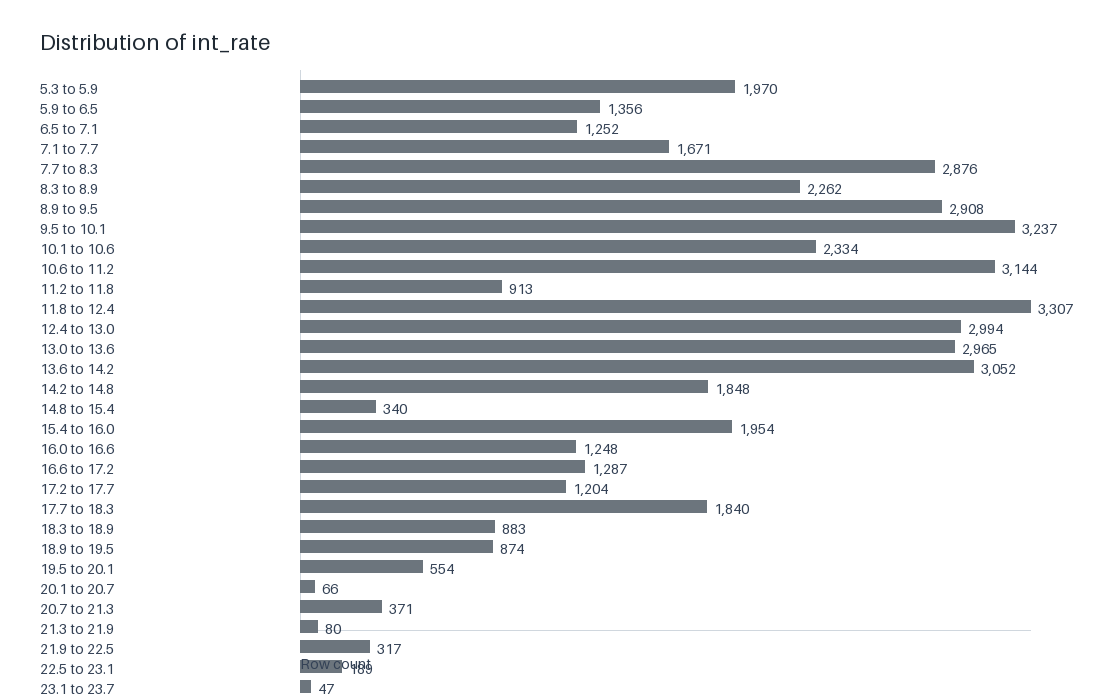

Numeric summary for annual_inc


,annual_inc
count,5.000000e+04
mean,7.919317e+04
std,1.013212e+05
min,0.000000e+00
25%,4.800000e+04
50%,6.600000e+04
75%,9.500000e+04
max,9.000000e+06


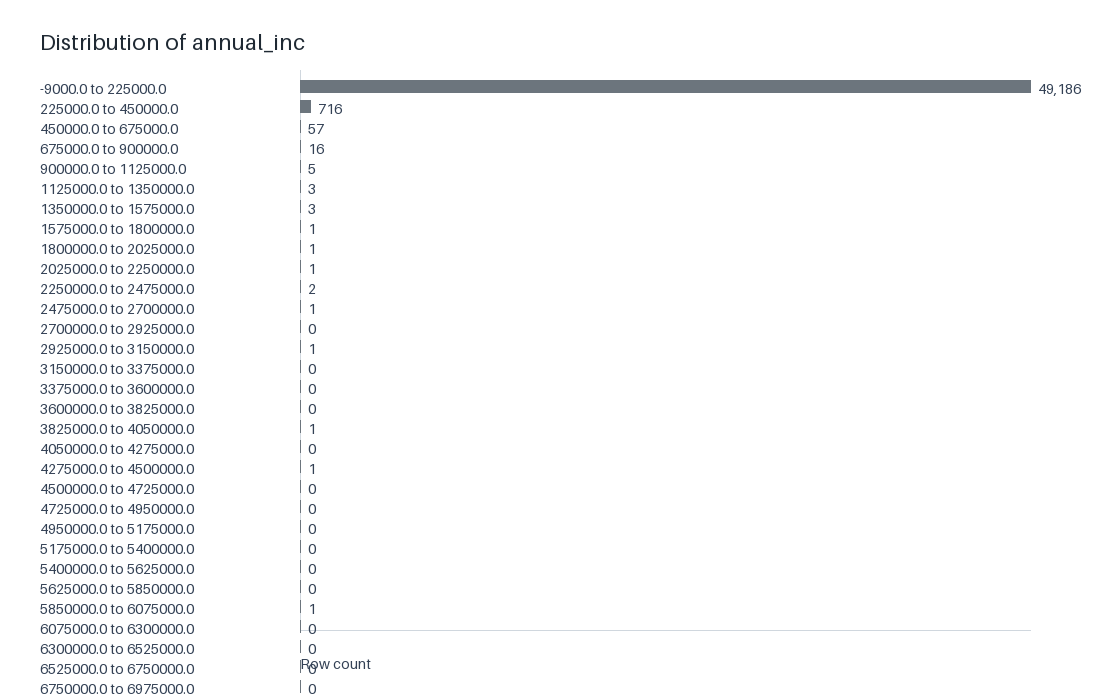

Numeric summary for dti


,dti
count,49999.000000
mean,19.338815
std,9.810057
min,0.000000
25%,12.680000
50%,18.820000
75%,25.615000
max,999.000000


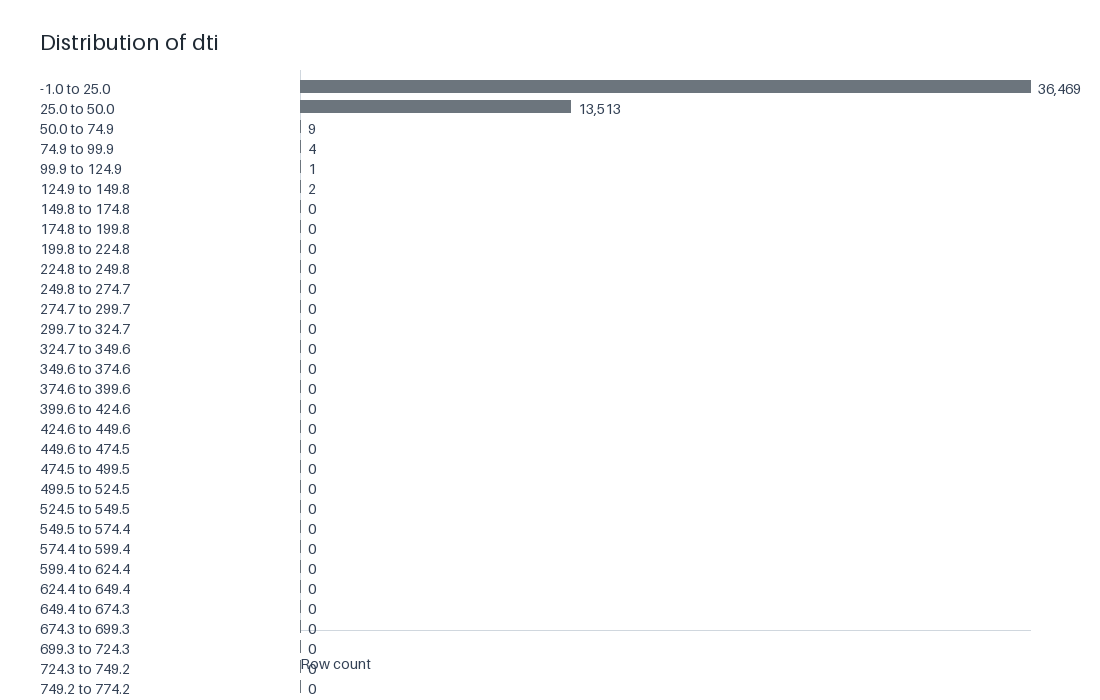

Saved numeric figures: ['numeric_distribution_loan_amnt.png', 'numeric_distribution_int_rate.png', 'numeric_distribution_annual_inc.png', 'numeric_distribution_dti.png']


In [11]:
numeric_checks = ["loan_amnt", "int_rate", "annual_inc", "dti"]
saved_numeric_figures = []

for column in numeric_checks:
    if column in modeling_ready.columns:
        numeric_summary = pd.to_numeric(modeling_ready[column], errors="coerce").describe().to_frame(column)
        print(f"Numeric summary for {column}")
        display(numeric_summary)

        image = plot_numeric_distribution(modeling_ready, column)
        figure_path = FIGURES_DIR / f"numeric_distribution_{column}.png"
        image.save(figure_path)
        saved_numeric_figures.append(figure_path.name)
        display(image)
    else:
        print(f"Skipped {column}: column not available.")

print("Saved numeric figures:", saved_numeric_figures)

## Initial Business Observations

In [12]:
observations = []
default_rate = modeling_ready["default_flag"].mean()
observations.append(f"The Phase 1 sample default rate is {default_rate:.2%} across {len(modeling_ready):,} rows with mapped target labels.")

for column in ["grade", "sub_grade", "term", "home_ownership", "purpose", "verification_status"]:
    if column in modeling_ready.columns:
        grouped = modeling_ready.groupby(column, dropna=False)["default_flag"].agg(default_rate="mean", row_count="size")
        grouped = grouped[grouped["row_count"] >= 100]
        if not grouped.empty:
            high_risk = grouped.sort_values("default_rate", ascending=False).head(1)
            low_risk = grouped.sort_values("default_rate", ascending=True).head(1)
            observations.append(
                f"For {column}, the highest observed default rate among groups with at least 100 rows is "
                f"{high_risk.index[0]} at {high_risk['default_rate'].iloc[0]:.2%}; "
                f"the lowest is {low_risk.index[0]} at {low_risk['default_rate'].iloc[0]:.2%}."
            )

for observation in observations:
    print(f"- {observation}")

- The Phase 1 sample default rate is 18.55% across 50,000 rows with mapped target labels.
- For grade, the highest observed default rate among groups with at least 100 rows is G at 49.55%; the lowest is A at 5.24%.
- For sub_grade, the highest observed default rate among groups with at least 100 rows is F5 at 61.95%; the lowest is A1 at 2.74%.
- For term, the highest observed default rate among groups with at least 100 rows is  60 months at 25.29%; the lowest is  36 months at 15.43%.
- For home_ownership, the highest observed default rate among groups with at least 100 rows is RENT at 21.86%; the lowest is MORTGAGE at 15.72%.
- For purpose, the highest observed default rate among groups with at least 100 rows is small_business at 28.84%; the lowest is car at 14.16%.
- For verification_status, the highest observed default rate among groups with at least 100 rows is Verified at 23.43%; the lowest is Not Verified at 13.11%.


## Phase 1 Limitations

- This notebook uses a maximum 50,000-row sample for GitHub-friendly exploration and output creation.
- Target mapping is based on initial LendingClub-style loan status categories and should be reviewed before modeling.
- No PD model has been trained.
- No LGD, EAD, staging, macroeconomic overlays, or IFRS 9 ECL assumptions have been implemented.
- Some columns may have high missingness and need feature-level treatment in Phase 2.

## Next Steps for Phase 2 PD Modeling

- Confirm the target definition and treatment of current or delinquent-but-not-defaulted accounts.
- Split the modeling sample into train and validation sets.
- Build preprocessing for categorical and numeric variables.
- Train a simple benchmark PD model.
- Evaluate discrimination, calibration, and business interpretability before ECL work begins.